# Probability of Exceedance Plot

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob

In [3]:
# dict for epochs
epochs = {
    'HIST': '/home/scratch/jcorner1/syn_sev/dataframes/HIST_UVV_[21]*_*',
    '8p5END': '/home/scratch/jcorner1/syn_sev/dataframes/EOC8p5_UVV*',
    '4p5END': '/home/scratch/jcorner1/syn_sev/dataframes/EOC4p5_UVV*',
    '8p5MID': '/home/scratch/jcorner1/syn_sev/dataframes/MC8p5_UVV*',
    '4p5MID': '/home/scratch/jcorner1/syn_sev/dataframes/MC4p5_UVV*'
}

# dict to store dataframes
df_epochs = {}

In [4]:
# loop through each epoch, load files, apply threshold and datetime operations
for epoch, path in epochs.items():
    # load files
    df = pd.concat(map(pd.read_csv, glob.glob(path)), ignore_index=True)
    
    # thresholding
    df = df[(df['DBZ'] >= 40.0) & (df['UVV'] >= 25.0)]
    
    # convert to datetime
    df['Time'] = pd.to_datetime(df['Time'])
    df['Date'] = df['Time'].dt.date
    df['Year'] = df['Time'].dt.year
    df['Month'] = df['Time'].dt.month
    
    # store dataframe in dict
    df_epochs[epoch] = df

In [5]:
# function calcs probability of exceedance and percentile
def calculate_poe(data):
    """
    Calculate probability of exceedance for a given dataset.
    Args:
        data (array-like): Array of counts of HCW events.
    Returns:
        sorted_data: Sorted values of data (descending).
        poe: Probability of exceedance for each value in sorted_data.
    """
    sorted_data = np.sort(data)[::-1]  # sort in descending order
    n = len(sorted_data)
    ranks = np.arange(1, n + 1)
    poe = ranks / (n + 1)  # prob of exceedance formula
    
    # function to calc 90th percentile
    percentile_90 = data.quantile(0.9)
    # percentile_50 = data.quantile(0.5)
    
    return sorted_data, poe, percentile_90

In [6]:
# colors for each epoch
colors = {
    'HIST': '#c5eabc',
    '8p5MID': '#ca6e74',
    '4p5MID': '#b5d6ea',
    '8p5END': '#a51017',
    '4p5END': '#006db3'
}

## PoE Plot for HCW Event Counts per Day

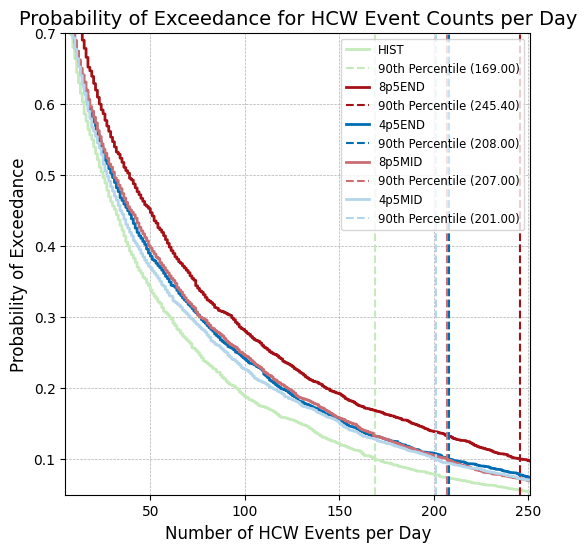

In [12]:
# plot POE curves
plt.figure(figsize=(6, 6))

# iterate over each epoch and plot POE curve for HCW event counts
for epoch, df in df_epochs.items():
    # count number of HCW events per day
    hcw_event_counts = df.groupby('Date').size()  # number of events per day
    
    # calc POE for these event counts
    sorted_data, poe, percentile_90 = calculate_poe(hcw_event_counts)
    
    # plot each curve
    plt.plot(sorted_data, poe, label=epoch, color=colors[epoch], linewidth=2)
    
    # plot vertical dashed lines for 90th percentile
    plt.axvline(x=percentile_90, color=colors[epoch], linestyle='dashed', label=f'90th Percentile ({percentile_90:.2f})')
    
plt.title('Probability of Exceedance for HCW Event Counts per Day', fontsize=14)
plt.xlabel('Number of HCW Events per Day', fontsize=12)
plt.ylabel('Probability of Exceedance', fontsize=12)
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0.05, 0.7)
plt.xlim(5, 251)
# plt.yscale('log')  # log scale for better vis

plt.savefig('../Plots/POE_CountsperDay2.jpg', format='jpg', dpi=500, bbox_inches='tight')

plt.show()

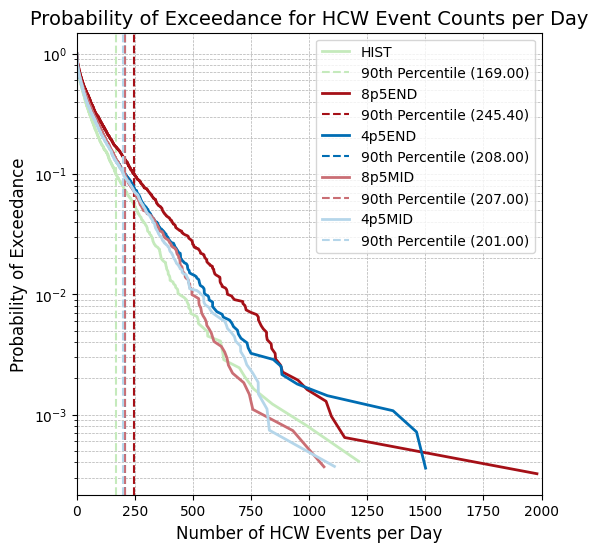

In [54]:
# plot POE curves LOG PLOT
plt.figure(figsize=(6, 6))

# iterate over each epoch and plot POE curve for HCW event counts
for epoch, df in df_epochs.items():
    # count number of HCW events per day
    hcw_event_counts = df.groupby('Date').size()  # number of events per day
    
    # calc POE for these event counts
    sorted_data, poe, percentile_90 = calculate_poe(hcw_event_counts)
    
    # plot each curve
    plt.plot(sorted_data, poe, label=epoch, color=colors[epoch], linewidth=2)

    # plot vertical dashed lines for 90th and 50th percentiles
    plt.axvline(x=percentile_90, color=colors[epoch], linestyle='dashed', label=f'90th Percentile ({percentile_90:.2f})')
    # plt.axvline(x=percentile_50, color=colors[epoch], linestyle='dashed', label=f'50th Percentile ({percentile_50:.2f})')
    
plt.title('Probability of Exceedance for HCW Event Counts per Day', fontsize=14)
plt.xlabel('Number of HCW Events per Day', fontsize=12)
plt.ylabel('Probability of Exceedance', fontsize=12)
plt.legend(loc='best')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlim(0,2000)
plt.yscale('log')  # log scale for better vis

plt.show()

## PoE Plot for Count of HCW Events per Year

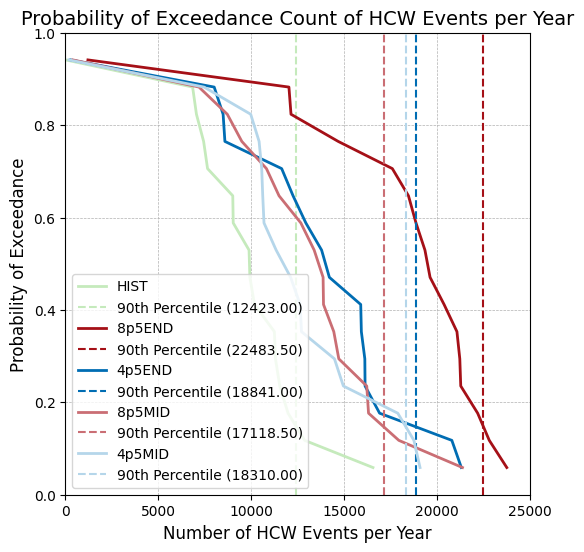

In [55]:
# POE curves for count of HCW events per year
plt.figure(figsize=(6, 6))
for epoch, df in df_epochs.items():
    # count number of HCW events per year
    hcw_event_counts_per_year = df.groupby('Year').size()
    
    # calc POE for yearly event counts
    sorted_data, poe, percentile_90 = calculate_poe(hcw_event_counts_per_year)
    
    # plot each curve
    plt.plot(sorted_data, poe, label=epoch, color=colors[epoch], linewidth=2)

    # plot vertical dashed line for 90th percentile
    plt.axvline(x=percentile_90, color=colors[epoch], linestyle='dashed', label=f'90th Percentile ({percentile_90:.2f})')
    
plt.title('Probability of Exceedance Count of HCW Events per Year', fontsize=14)
plt.xlabel('Number of HCW Events per Year', fontsize=12)
plt.ylabel('Probability of Exceedance', fontsize=12)
plt.legend(loc='best')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0, 1.0)
plt.xlim(0, 25000)
# plt.yscale('log')

plt.show()

## POE Plot of HCW Days per Year

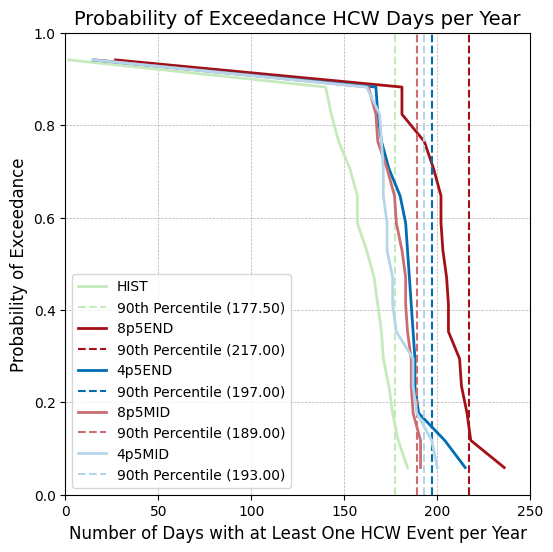

In [56]:
# POE curves for the number of days per year with at least one HCW event
plt.figure(figsize=(6, 6))
for epoch, df in df_epochs.items():
    # count number of days per year with at least one HCW event
    days_with_hcw_event_per_year = df.groupby(['Year', 'Date']).size().groupby('Year').apply(lambda x: (x > 0).sum())
    
    # calc POE for yearly day counts
    sorted_data, poe, percentile_90 = calculate_poe(days_with_hcw_event_per_year)
    
    # plot each curve
    plt.plot(sorted_data, poe, label=epoch, color=colors[epoch], linewidth=2)

    # plot vertical dashed line for 90th percentile
    plt.axvline(x=percentile_90, color=colors[epoch], linestyle='dashed', label=f'90th Percentile ({percentile_90:.2f})')
    
plt.title('Probability of Exceedance HCW Days per Year', fontsize=14)
plt.xlabel('Number of Days with at Least One HCW Event per Year', fontsize=12)
plt.ylabel('Probability of Exceedance', fontsize=12)
plt.legend(loc='best')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0,1.0)
plt.xlim(0,250)
# plt.yscale('log')

plt.show()